# Political Compass MCQ–chat comparison — primary models


    This notebook compares English MCQ and chat configuration coordinates for
    the paper's eight primary checkpoints. Displays follow the paper ordering:
    Gemma MCQ then chat by size; Qwen MCQ, no-think chat and think chat by size.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'core.py').exists():
    candidates = [Path('tasks/political-compass/analysis').resolve(), Path.cwd().parent]
    ANALYSIS_DIR = next((path for path in candidates if (path / 'core.py').exists()), None)
if ANALYSIS_DIR is None:
    raise FileNotFoundError('Run from the repository root or tasks/political-compass/analysis.')
sys.path.insert(0, str(ANALYSIS_DIR))

from core import (
    GEMMA_MODELS, QWEN_MODELS, PRIMARY_MODELS, IDEOLOGY_ORDER,
    load_mcq_configurations, load_chat_configurations, method_order,
    plot_centroid_grid, qwen_think_outcomes, descriptive_factor_spread,
    plot_sensitivity_heatmap, size_label,
)

sns.set_theme(style='whitegrid', context='notebook')

## Coverage and comparable methods

In [2]:
mcq=load_mcq_configurations()
mcq=mcq[mcq.language.str.lower().eq('english')].rename(columns={'score_econ':'economic','score_soc':'social'})
chat=load_chat_configurations()
display(pd.DataFrame({'method':['MCQ English','Chat English'],
                      'configuration rows':[len(mcq),len(chat)],
                      'base models':[mcq.base_model.nunique(),chat.base_model.nunique()]}))
# Language is sampled by the Latin-hypercube design rather than crossed
# exhaustively, so the English MCQ subset contains 3,024 rows.
assert len(mcq)==3_024 and len(chat)==21_600

,method,configuration rows,base models
0,MCQ English,3024,8
1,Chat English,21600,8


## Family-grouped configuration maps

        Every subplot uses the same −10…10 axes. Individual points show prompt
        configurations; large markers show assigned-persona centroids; ellipses
        show one standard deviation along covariance axes.

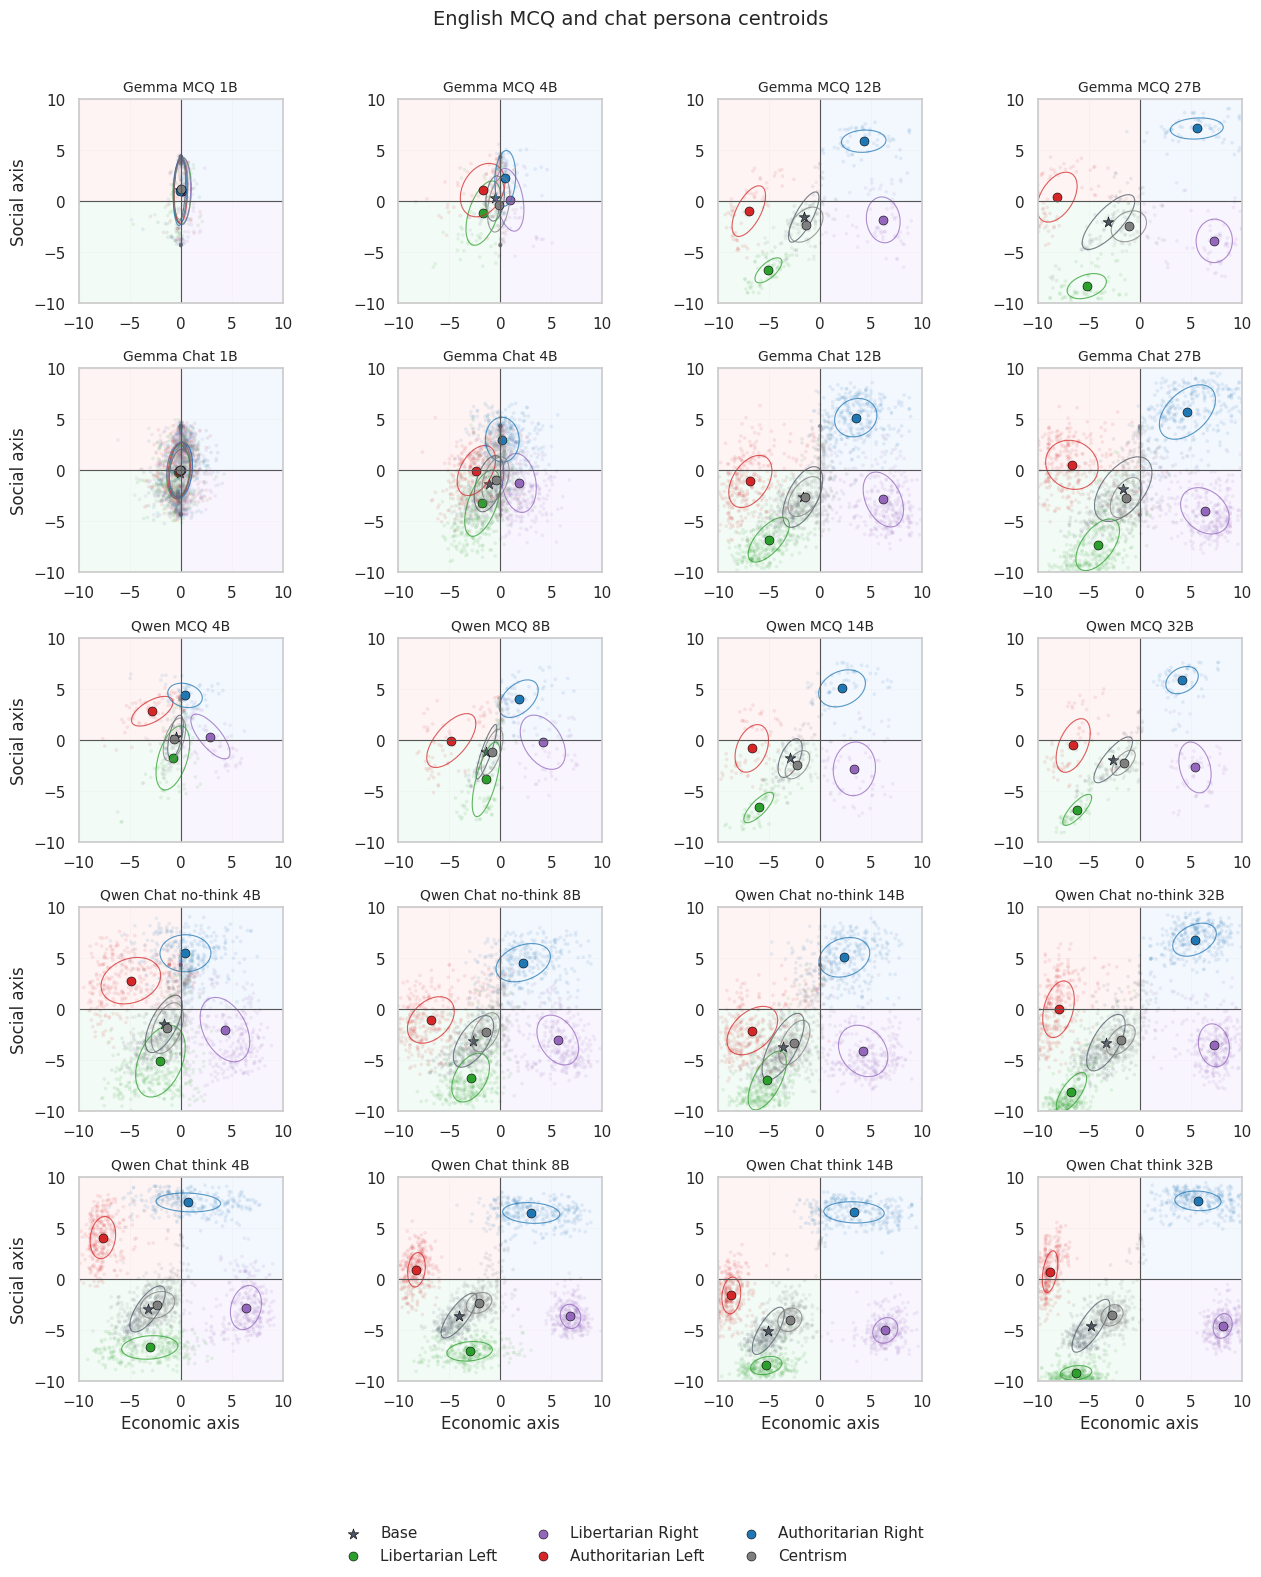

In [3]:
combined=pd.concat([mcq[['base_model','protocol','ideology','economic','social']],
                    chat[['base_model','protocol','ideology','economic','social']]],ignore_index=True)
panels=[(f'{m}|{p}',label) for m,p,label in method_order()]
fig=plot_centroid_grid(combined,panels,ncols=4,title='English MCQ and chat persona centroids')
plt.show()

## Persona-centroid displacement

        Each cell is the Euclidean distance between the English MCQ persona
        centroid and its chat counterpart. Larger values identify a larger
        protocol shift for this model/persona; they are not quality scores.

In [4]:
mcq_cent=mcq.groupby(['base_model','ideology'])[['economic','social']].mean()
chat_cent=chat.groupby(['base_model','protocol','ideology'])[['economic','social']].mean()
rows=[]
for (model,protocol,ideology),point in chat_cent.iterrows():
    ref=mcq_cent.loc[(model,ideology)]
    rows.append({'model':model,'protocol':protocol,'ideology':ideology,
                 'distance':float(np.linalg.norm(point.to_numpy()-ref.to_numpy())),
                 'economic_delta':point.economic-ref.economic,
                 'social_delta':point.social-ref.social})
displacement=pd.DataFrame(rows)
display(displacement.pivot_table(index=['model','protocol'],columns='ideology',values='distance').round(2))

ideology                 authoritarian_left  authoritarian_right  base  \
model          protocol                                                  
Qwen3-14B      no_think                1.25                 0.23  1.99   
               think                   2.16                 1.88  3.94   
Qwen3-32B      no_think                1.55                 1.56  1.49   
               think                   2.59                 2.37  3.43   
Qwen3-4B       no_think                2.10                 1.14  2.06   
               think                   5.00                 3.15  4.25   
Qwen3-8B       no_think                2.23                 0.69  2.35   
               think                   3.55                 2.71  3.64   
gemma-3-12b-it standard                0.17                 1.04  1.03   
gemma-3-1b-it  standard                1.08                 0.92  1.30   
gemma-3-27b-it standard                1.46                 1.66  1.47   
gemma-3-4b-it  standard                1.24                 0.85  1.66   

ideology                 centrism  libertarian_left  libertarian_right  
model          protocol                                                 
Qwen3-14B      no_think      0.87              0.91               1.51  
               think         1.74              2.01               3.75  
Qwen3-32B      no_think      0.79              1.39               2.03  
               think         1.75              2.36               3.32  
Qwen3-4B       no_think      2.00              3.53               2.72  
               think         3.09              5.45               4.70  
Qwen3-8B       no_think      1.21              3.21               3.13  
               think         1.72              3.62               4.39  
gemma-3-12b-it standard      0.27              0.03               1.00  
gemma-3-1b-it  standard      1.15              1.16               0.93  
gemma-3-27b-it standard      0.32              1.51               0.92  
gemma-3-4b-it  standard      0.61              2.02               1.62

## Axis-specific protocol shifts

        Signed deltas preserve direction: positive economic values move right;
        positive social values move upward. This table makes clear when a large
        distance is economic, social, or both.

In [5]:
axis_summary=(displacement.groupby(['model','protocol'],observed=True)
              .agg(mean_distance=('distance','mean'),
                   mean_abs_economic_shift=('economic_delta',lambda x:np.abs(x).mean()),
                   mean_abs_social_shift=('social_delta',lambda x:np.abs(x).mean()),
                   max_persona_distance=('distance','max')))
display(axis_summary.round(3))

mean_distance  mean_abs_economic_shift  \
model          protocol                                           
Qwen3-14B      no_think          1.126                    0.497   
               think             2.580                    1.640   
Qwen3-32B      no_think          1.467                    1.011   
               think             2.636                    1.664   
Qwen3-4B       no_think          2.258                    1.103   
               think             4.270                    2.555   
Qwen3-8B       no_think          2.139                    1.222   
               think             3.270                    2.158   
gemma-3-12b-it standard          0.589                    0.197   
gemma-3-1b-it  standard          1.090                    0.156   
gemma-3-27b-it standard          1.223                    1.013   
gemma-3-4b-it  standard          1.332                    0.468   

                         mean_abs_social_shift  max_persona_distance  
model          protocol                                               
Qwen3-14B      no_think                  0.927                 1.988  
               think                     1.870                 3.937  
Qwen3-32B      no_think                  0.946                 2.032  
               think                     1.880                 3.427  
Qwen3-4B       no_think                  1.728                 3.531  
               think                     3.052                 5.446  
Qwen3-8B       no_think                  1.687                 3.209  
               think                     2.276                 4.388  
gemma-3-12b-it standard                  0.506                 1.036  
gemma-3-1b-it  standard                  1.070                 1.295  
gemma-3-27b-it standard                  0.513                 1.656  
gemma-3-4b-it  standard                  1.216                 2.017

## Shared factor sensitivity

        MCQ and chat do not expose identical factors. The table compares only
        descriptive spreads available in each released configuration table and
        leaves non-applicable factors absent. Do not read white/missing cells
        as zero sensitivity.

In [6]:
mcq_for_spread=mcq.copy()
mcq_for_spread['context_id']=mcq_for_spread.context_combo
mcq_for_spread['persona_class']=mcq_for_spread.persona_combo
mcq_spread=descriptive_factor_spread(mcq_for_spread,('economic','social'),
             ('context_id','instr_combo','key_type','perm_id','persona_class'))
chat_spread=descriptive_factor_spread(chat,('economic','social'),
             ('reasoning_mode','context_id','persona_class'))
sensitivity=pd.concat([mcq_spread,chat_spread],ignore_index=True,sort=False)
display(sensitivity.round(3))

,base_model,protocol,economic: total SD,economic: persona SD,economic: context_id,economic: instr_combo,economic: key_type,economic: perm_id,economic: persona_class,social: total SD,social: persona SD,social: context_id,social: instr_combo,social: key_type,social: perm_id,social: persona_class,economic: reasoning_mode,social: reasoning_mode
0,Qwen3-14B,mcq,4.125,3.767,0.563,1.152,0.605,0.670,1.230,3.989,3.474,1.089,1.403,0.688,0.923,1.168,NaN,NaN
1,Qwen3-32B,mcq,4.860,4.605,0.613,1.150,0.792,0.625,0.963,4.271,3.785,0.849,1.329,0.803,0.959,1.507,NaN,NaN
2,Qwen3-4B,mcq,2.323,1.703,0.616,1.108,0.633,0.494,1.047,2.910,2.005,0.808,1.264,1.125,0.851,0.859,NaN,NaN
3,Qwen3-8B,mcq,3.300,2.805,0.923,1.208,0.625,0.552,1.041,3.546,2.350,1.553,1.605,0.840,1.303,1.529,NaN,NaN
4,gemma-3-12b-it,mcq,4.979,4.692,0.895,1.053,0.570,0.651,1.161,4.197,3.721,1.190,1.490,0.692,0.884,1.195,NaN,NaN
5,gemma-3-1b-it,mcq,0.727,0.087,0.161,0.261,0.190,0.221,0.238,3.184,0.070,1.101,2.797,0.734,1.590,1.425,NaN,NaN
6,gemma-3-27b-it,mcq,5.933,5.546,0.977,1.605,0.815,0.716,1.376,5.065,4.684,1.044,1.522,0.814,0.822,1.204,NaN,NaN
7,gemma-3-4b-it,mcq,1.754,0.996,0.762,1.073,0.433,0.431,0.889,2.945,1.076,0.865,1.882,1.267,1.237,1.467,NaN,NaN
8,Qwen3-14B,no_think,4.484,3.926,0.462,NaN,NaN,NaN,0.350,4.506,3.707,0.757,NaN,NaN,NaN,0.509,0.514,0.643
9,Qwen3-14B,think,5.512,5.243,0.435,NaN,NaN,NaN,0.843,4.929,4.698,0.640,NaN,NaN,NaN,0.492,0.164,0.284


## Exact matched Qwen protocol comparison

        Think/no-think configurations share their sampled LHS keys. MCQ uses a
        different experimental design, so MCQ–chat comparisons above are made
        at persona-centroid level rather than falsely pairing individual rows.

In [7]:
keys=['base_model','ideology','lhs_row','reasoning_mode','context_id','persona_class']
paired=chat[chat.base_model.isin(QWEN_MODELS)].pivot_table(index=keys,columns='protocol',
            values=['economic','social','target_quadrant_correct'],aggfunc='first').dropna()
result=[]
for model in QWEN_MODELS:
    sub=paired.xs(model,level='base_model')
    result.append({'model':model,'matched configurations':len(sub),
                   'mean economic shift':(sub[('economic','think')]-sub[('economic','no_think')]).mean(),
                   'mean social shift':(sub[('social','think')]-sub[('social','no_think')]).mean(),
                   'think quadrant rate':sub[('target_quadrant_correct','think')].mean(),
                   'no-think quadrant rate':sub[('target_quadrant_correct','no_think')].mean()})
display(pd.DataFrame(result).set_index('model').round(3))

,matched configurations,mean economic shift,mean social shift,think quadrant rate,no-think quadrant rate
model,,,,,
Qwen3-4B,1800,-0.670,-0.249,0.545,0.465
Qwen3-8B,1800,-0.258,0.358,0.577,0.479
Qwen3-14B,1800,-0.157,-0.470,0.506,0.478
Qwen3-32B,1800,-0.254,-0.434,0.601,0.569


## Interpretation boundary

        Protocol differences are large in some model/persona cells and modest
        in others. The analysis supports method-specific heterogeneity; it does
        not justify a universal MCQ-versus-chat or think-versus-no-think law.